In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
df = pd.read_csv('../datasets/final_dataset_missing_value_imputed_v5.csv')


In [3]:
df.head()


,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,property_id,builtup_area,study room,pooja room,store room,servant room,others,furnishing_type,facility_score
0,house,independent,sector 25,4.35,32222.0,5,4,3,3.0,Old Property,R70162684,1350.0,0,0,0,1,0,0,49
1,flat,the close south,sector 50,3.10,12444.0,3,4,3+,4.0,Moderately Old,H69433380,2450.0,0,0,0,1,0,2,165
2,flat,signature global city 63a,sector 63a,1.65,15263.0,2,2,2,1.0,Under Construction,G69165782,978.0,0,0,0,0,0,0,0
3,flat,saan verdante,sector 95,2.00,10178.0,3,4,3+,5.0,New Property,U70096330,1964.0,0,0,0,1,0,0,49
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,Relatively New,S69742910,2996.0,0,0,0,1,0,1,160


In [4]:
latlong = pd.read_csv('../datasets/latlong.csv')
latlong.head()


,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"


In [5]:
# differentiate lattitude and longitude
latlong['latitude'] = latlong['coordinates'].str.split(",").str.get(0).str.split('°').str.get(0).astype('float')

latlong['longitude'] = latlong['coordinates'].str.split(",").str.get(1).str.split('°').str.get(0).astype('float')


In [6]:
latlong.sample(5)


,sector,coordinates,latitude,longitude
34,sector 32,"28.4472° N, 77.0406° E",28.4472,77.0406
91,sector 83,"28.3986° N, 76.9647° E",28.3986,76.9647
119,sector 108,"28.5134° N, 76.9830° E",28.5134,76.9830
74,sector 67a,"28.3960° N, 77.0372° E",28.3960,77.0372
79,sector 72,"28.4225° N, 77.0211° E",28.4225,77.0211


In [7]:
# merging on the basis of sector
new_df = df.merge(latlong, on='sector')


In [8]:
new_df.head()


,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,...,study room,pooja room,store room,servant room,others,furnishing_type,facility_score,coordinates,latitude,longitude
0,house,independent,sector 25,4.35,32222.0,5,4,3,3.0,Old Property,...,0,0,0,1,0,0,49,"28.4844° N, 77.0860° E",28.4844,77.0860
1,flat,the close south,sector 50,3.10,12444.0,3,4,3+,4.0,Moderately Old,...,0,0,0,1,0,2,165,"28.4178° N, 77.0628° E",28.4178,77.0628
2,flat,signature global city 63a,sector 63a,1.65,15263.0,2,2,2,1.0,Under Construction,...,0,0,0,0,0,0,0,"28.3923° N, 77.0888° E",28.3923,77.0888
3,flat,saan verdante,sector 95,2.00,10178.0,3,4,3+,5.0,New Property,...,0,0,0,1,0,0,49,"28.4172° N, 76.9081° E",28.4172,76.9081
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,4,5,3+,6.0,Relatively New,...,0,0,0,1,0,1,160,"28.5238° N, 77.0320° E",28.5238,77.0320


In [9]:
# grouping by sector to get mean price of each sector
grouped = new_df.groupby('sector')
mean_groups = grouped.mean(numeric_only=True)
# print(mean_groups.columns)
group_df = mean_groups[['price', 'price_per_sqft', 'builtup_area', 'latitude', 'longitude']]


In [10]:
group_df.head()


,price,price_per_sqft,builtup_area,latitude,longitude
sector,,,,,
gwal pahari,2.938824,9708.588235,2703.588235,28.4484,77.0210
manesar,0.962258,4607.838710,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.500000,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.719626,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.476190,1865.428571,28.4949,76.9845


In [11]:
fig = px.scatter_mapbox(group_df, lat='latitude', lon='longitude', color='price_per_sqft', size='builtup_area',
                        color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                        mapbox_style='open-street-map', text=group_df.index)

fig.show()


C:\Users\hp\AppData\Local\Temp\ipykernel_20648\3401756387.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat='latitude', lon='longitude', color='price_per_sqft', size='builtup_area',


In [12]:
new_df.to_csv('../datasets/final_dataset_with_latlong.csv')


### word cloud

In [13]:
df1 = pd.read_csv('../datasets/final_dataset_cleaned_v1.csv')


In [ ]:
df1.head()


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_id
0,house,independent,sector 25,4.35,32222.0,1350.0,Plot area 150(125.42 sq.m.),5,4,3,servant room,3.0,North,10+ Year Old,"['Vodafone belvedere towers metro station', 'D...",[],"['Feng Shui / Vaastu Compliant', 'Private Gard...",R70162684
1,flat,the close south,sector 50,3.10,12444.0,2491.0,Super Built up area 2491(231.42 sq.m.)Built Up...,3,4,3+,servant room,4.0,North-East,5 to 10 Year Old,"['Fresco Market', 'Emerald Plaza', 'Tagore Pub...","['4 Wardrobe', '8 Fan', '1 Exhaust Fan', '3 Ge...","['Centrally Air Conditioned', 'Water purifier'...",H69433380
2,flat,signature global city 63a,sector 63a,1.65,15263.0,1081.0,Super Built up area 1081(100.43 sq.m.),2,2,2,not available,1.0,NaN,Oct 2024,"['Sector 54 Chowk Metro Station', 'Paras Trini...","['1 Wardrobe', '1 Fan', '1 Light', '1 AC', 'No...",NaN,G69165782
3,flat,saan verdante,sector 95,2.00,10178.0,1965.0,Super Built up area 1965(182.55 sq.m.)Carpet a...,3,4,3+,servant room,5.0,North,0 to 1 Year Old,"['Proposed Metro Station', 'Dwarka Expressway'...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...",U70096330
4,flat,puri diplomatic greens,sector 111,3.90,13000.0,3000.0,Super Built up area 3000(278.71 sq.m.)Carpet a...,4,5,3+,servant room,6.0,North-East,1 to 5 Year Old,"['Dwarka Sector 21 Metro Station', 'Gurgaon Dr...","['1 Water Purifier', '6 Fan', '1 Fridge', '1 E...","['Centrally Air Conditioned', 'Water purifier'...",S69742910


In [16]:
# merging on the basis of sector
wc_df = df1[['features', 'sector']]
wc_df.head()


,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Private Gard...",sector 25
1,"['Centrally Air Conditioned', 'Water purifier'...",sector 50
2,NaN,sector 63a
3,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 95
4,"['Centrally Air Conditioned', 'Water purifier'...",sector 111


In [20]:
# main list where all the amenities will be stored
main = []

import ast
for item in wc_df['features'].dropna().apply(ast.literal_eval):
        main.extend(item)


In [21]:
main


['Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Centrally Air Conditioned',
 'Water purifier',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff'

In [22]:
from wordcloud import WordCloud

feature_text = " ".join(main)


In [ ]:
feature_text


'Feng Shui / Vaastu Compliant Private Garden / Terrace Maintenance Staff Water Storage Park Visitor Parking Waste Disposal Rain Water Harvesting Centrally Air Conditioned Water purifier Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Centrally Air Conditioned Water purifier Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Private Garden / Terrace Interco

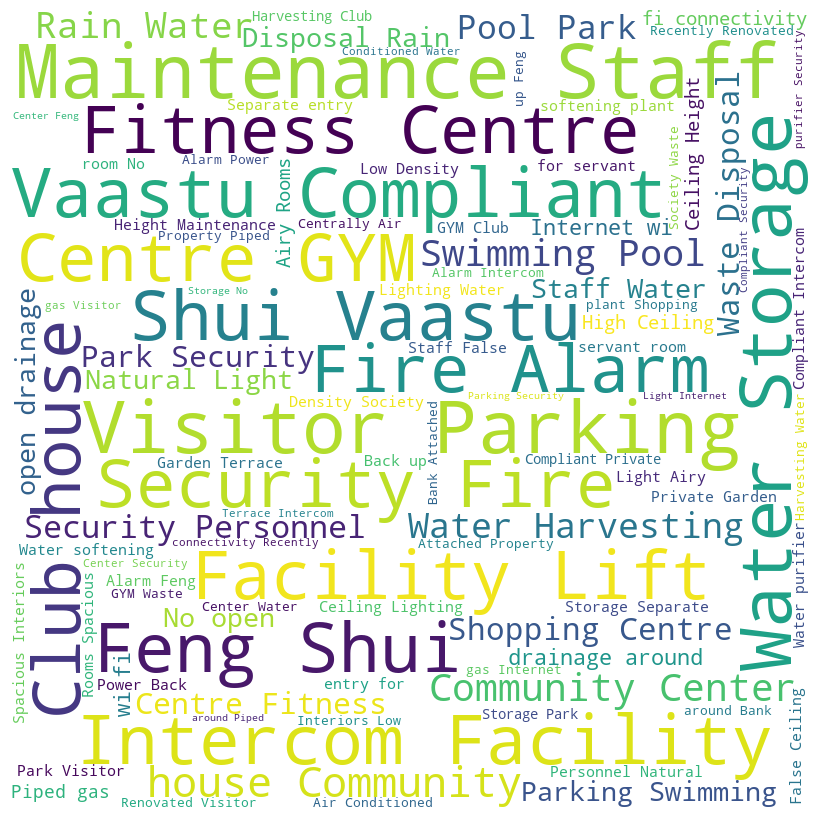

In [24]:
# plotting the wordcloud

plt.rcParams['font.family'] = 'Arial'

wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=set(['s']),
                      min_font_size=10).generate(feature_text)

plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()


In [25]:
import pickle

pickle.dump(feature_text, open('../models/feature_text.pkl', 'wb'))


### scatter plot

In [26]:
fig = px.scatter(df, x='builtup_area', y='price', color='bedRoom', title='Area vs Price')
fig.show()


### piechart

In [29]:
fig3 = px.pie(df, names='bedRoom', title="")
fig3.show()


### boxplot

In [30]:
temp_df = df[df['bedRoom'] <= 4]
fig = px.box(temp_df, x='bedRoom', y='price',)

fig.show()


### distplot

C:\Users\hp\AppData\Local\Temp\ipykernel_20648\2436242274.py:1: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751


C:\Users\hp\AppData\Local\Temp\ipykernel_20648\2436242274.py:2: UserWarning:



`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751




<Axes: xlabel='price', ylabel='Density'>

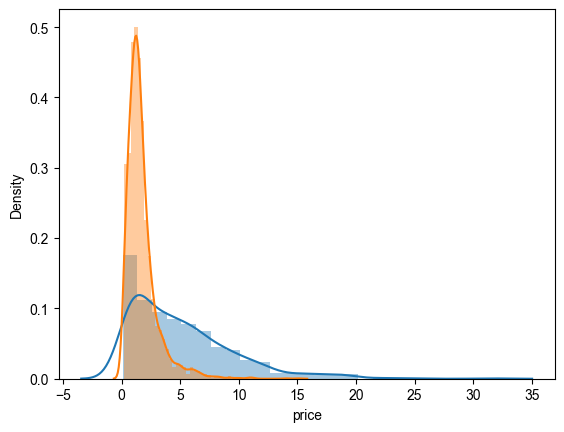

In [33]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])
